In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import numpy as np
import pandas as pd 
import os

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "nalisha/job-salary-prediction-dataset",
    "job_salary_prediction_dataset.csv",
    )

# Step 1 - EDA

In [3]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


Data type for each feature looks correct.

In [4]:
(df.isnull().sum()/(len(df)))*100

job_title           0.0
experience_years    0.0
education_level     0.0
skills_count        0.0
industry            0.0
company_size        0.0
location            0.0
remote_work         0.0
certifications      0.0
salary              0.0
dtype: float64

There are no null values.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
experience_years,250000.0,10.005408,6.060602,0.0,5.0,10.0,15.0,20.0
skills_count,250000.0,9.997812,5.479288,1.0,5.0,10.0,15.0,19.0
certifications,250000.0,2.491928,1.706475,0.0,1.0,2.0,4.0,5.0
salary,250000.0,145718.080524,37407.952729,31867.0,119358.0,143453.0,169492.0,333046.0


Ranges of values look appropirate. We don't see any outliers at a first glance.

Overall, this dataset is high-quality and does not require any fixing.

# Step 2 - EDA graph plot

In [6]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64']).columns
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')
Numerical Variables:
Index(['experience_years', 'skills_count', 'certifications', 'salary'], dtype='object')


experience_years
Skew : -0.0


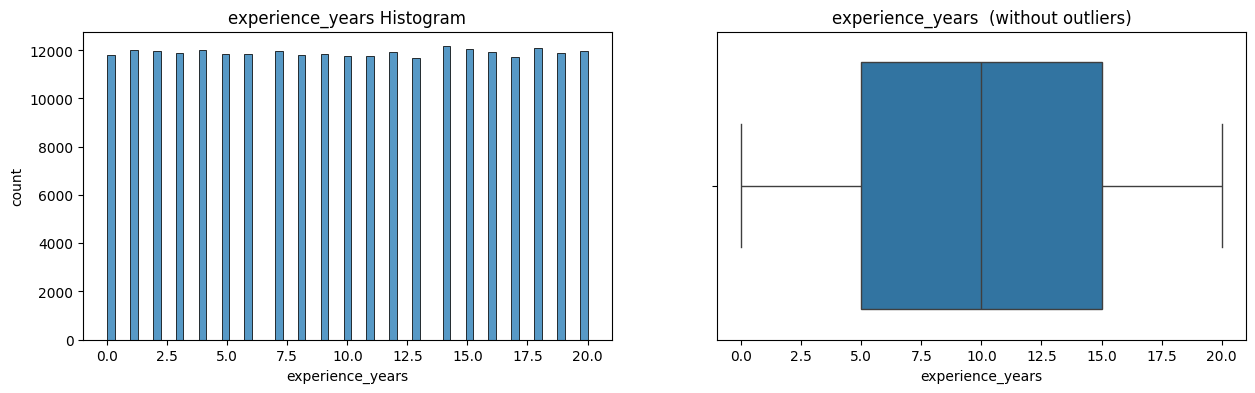

skills_count
Skew : 0.0


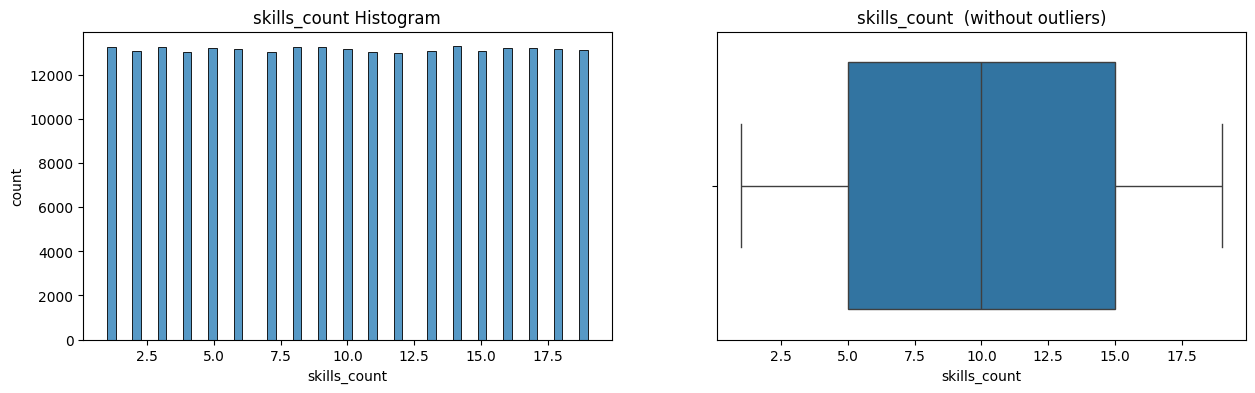

certifications
Skew : 0.0


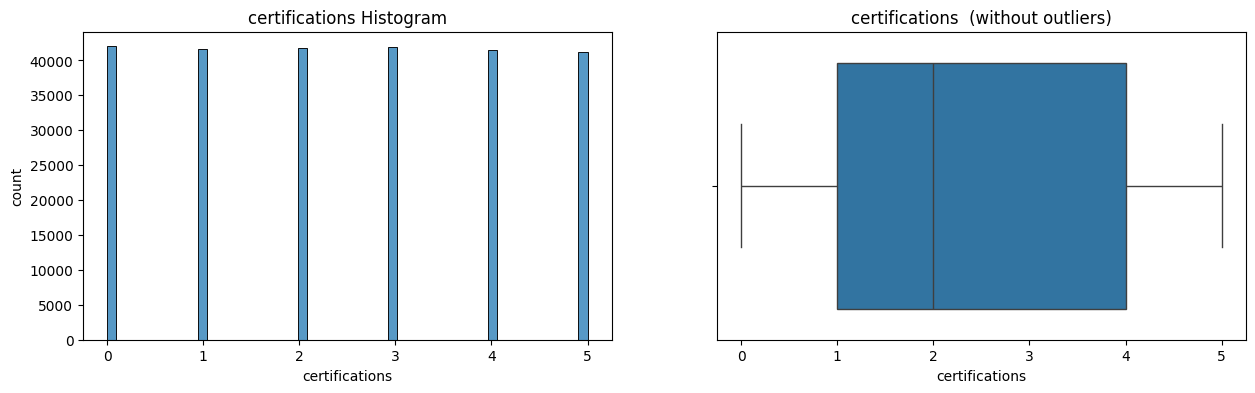

salary
Skew : 0.38


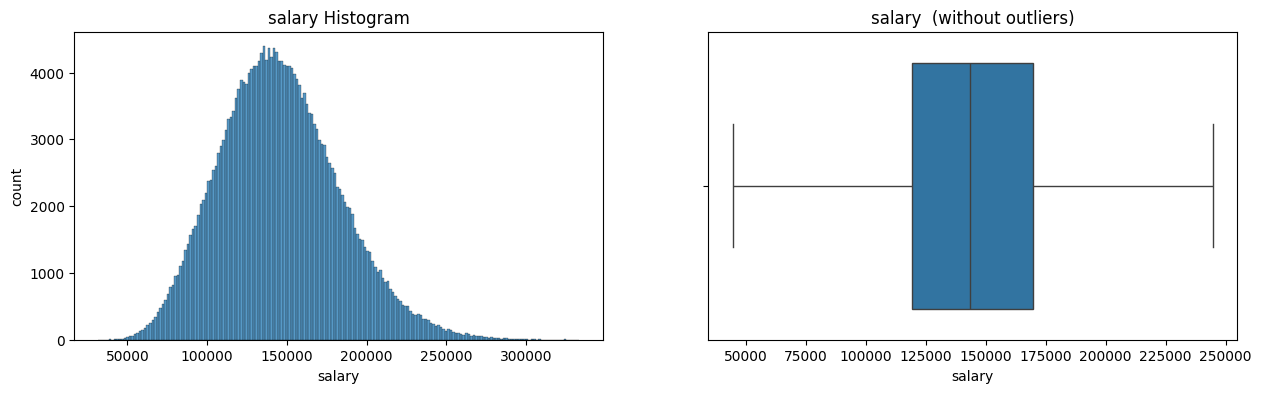

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f'{col}  (without outliers)')
    
    plt.show()

We are seeing a lot of uniform distribution for most numerical metrics except salary.

Salary is the only feature that is normally distrbuted but it is very slightly skewed to the right. 

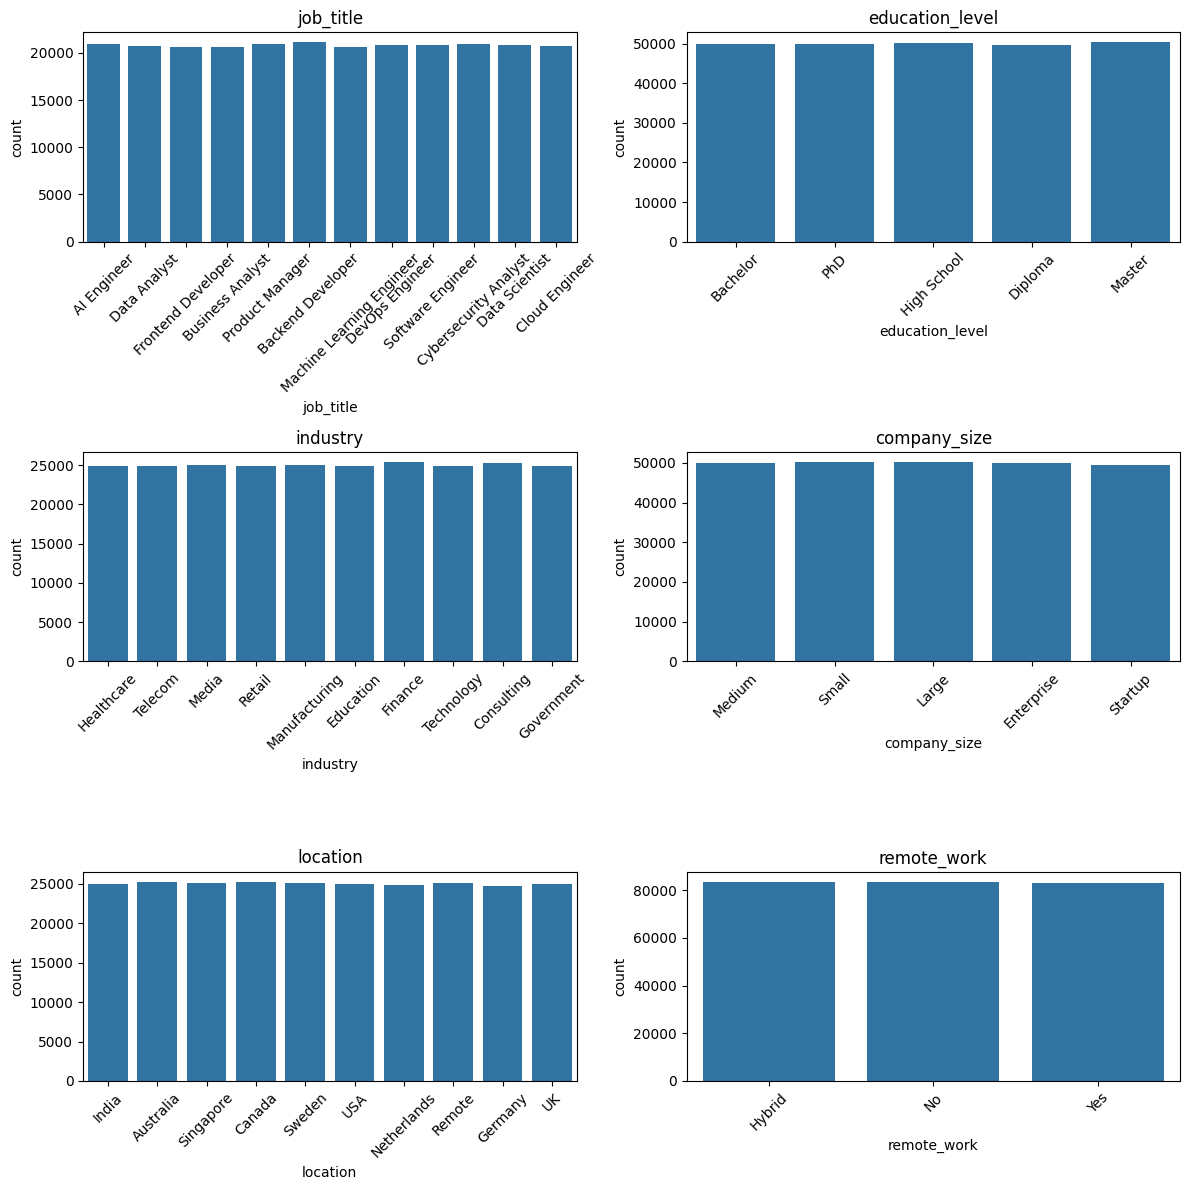

In [8]:
import math 

plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

Each category also has the same amount of data. Dataset is very balanced.

# Step 3 - Data transformation

We can fix the small salary skew by using Box-Cox

Optimal lambda: 0.49236621260401514


/tmp/ipykernel_24/807511014.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(transformed_data, axlabel="BoxCox");


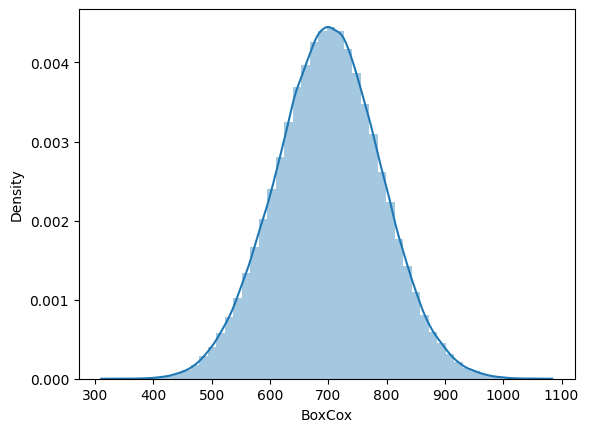

In [9]:
from scipy import stats
from scipy.special import inv_boxcox

transformed_data, lambda_opt = stats.boxcox(df['salary'])
df['salary'] = transformed_data
print(f"Optimal lambda: {lambda_opt}") # needed for converting transformed salary back to its original value
sns.distplot(transformed_data, axlabel="BoxCox");

# Step 4 - Bivariate Analysis

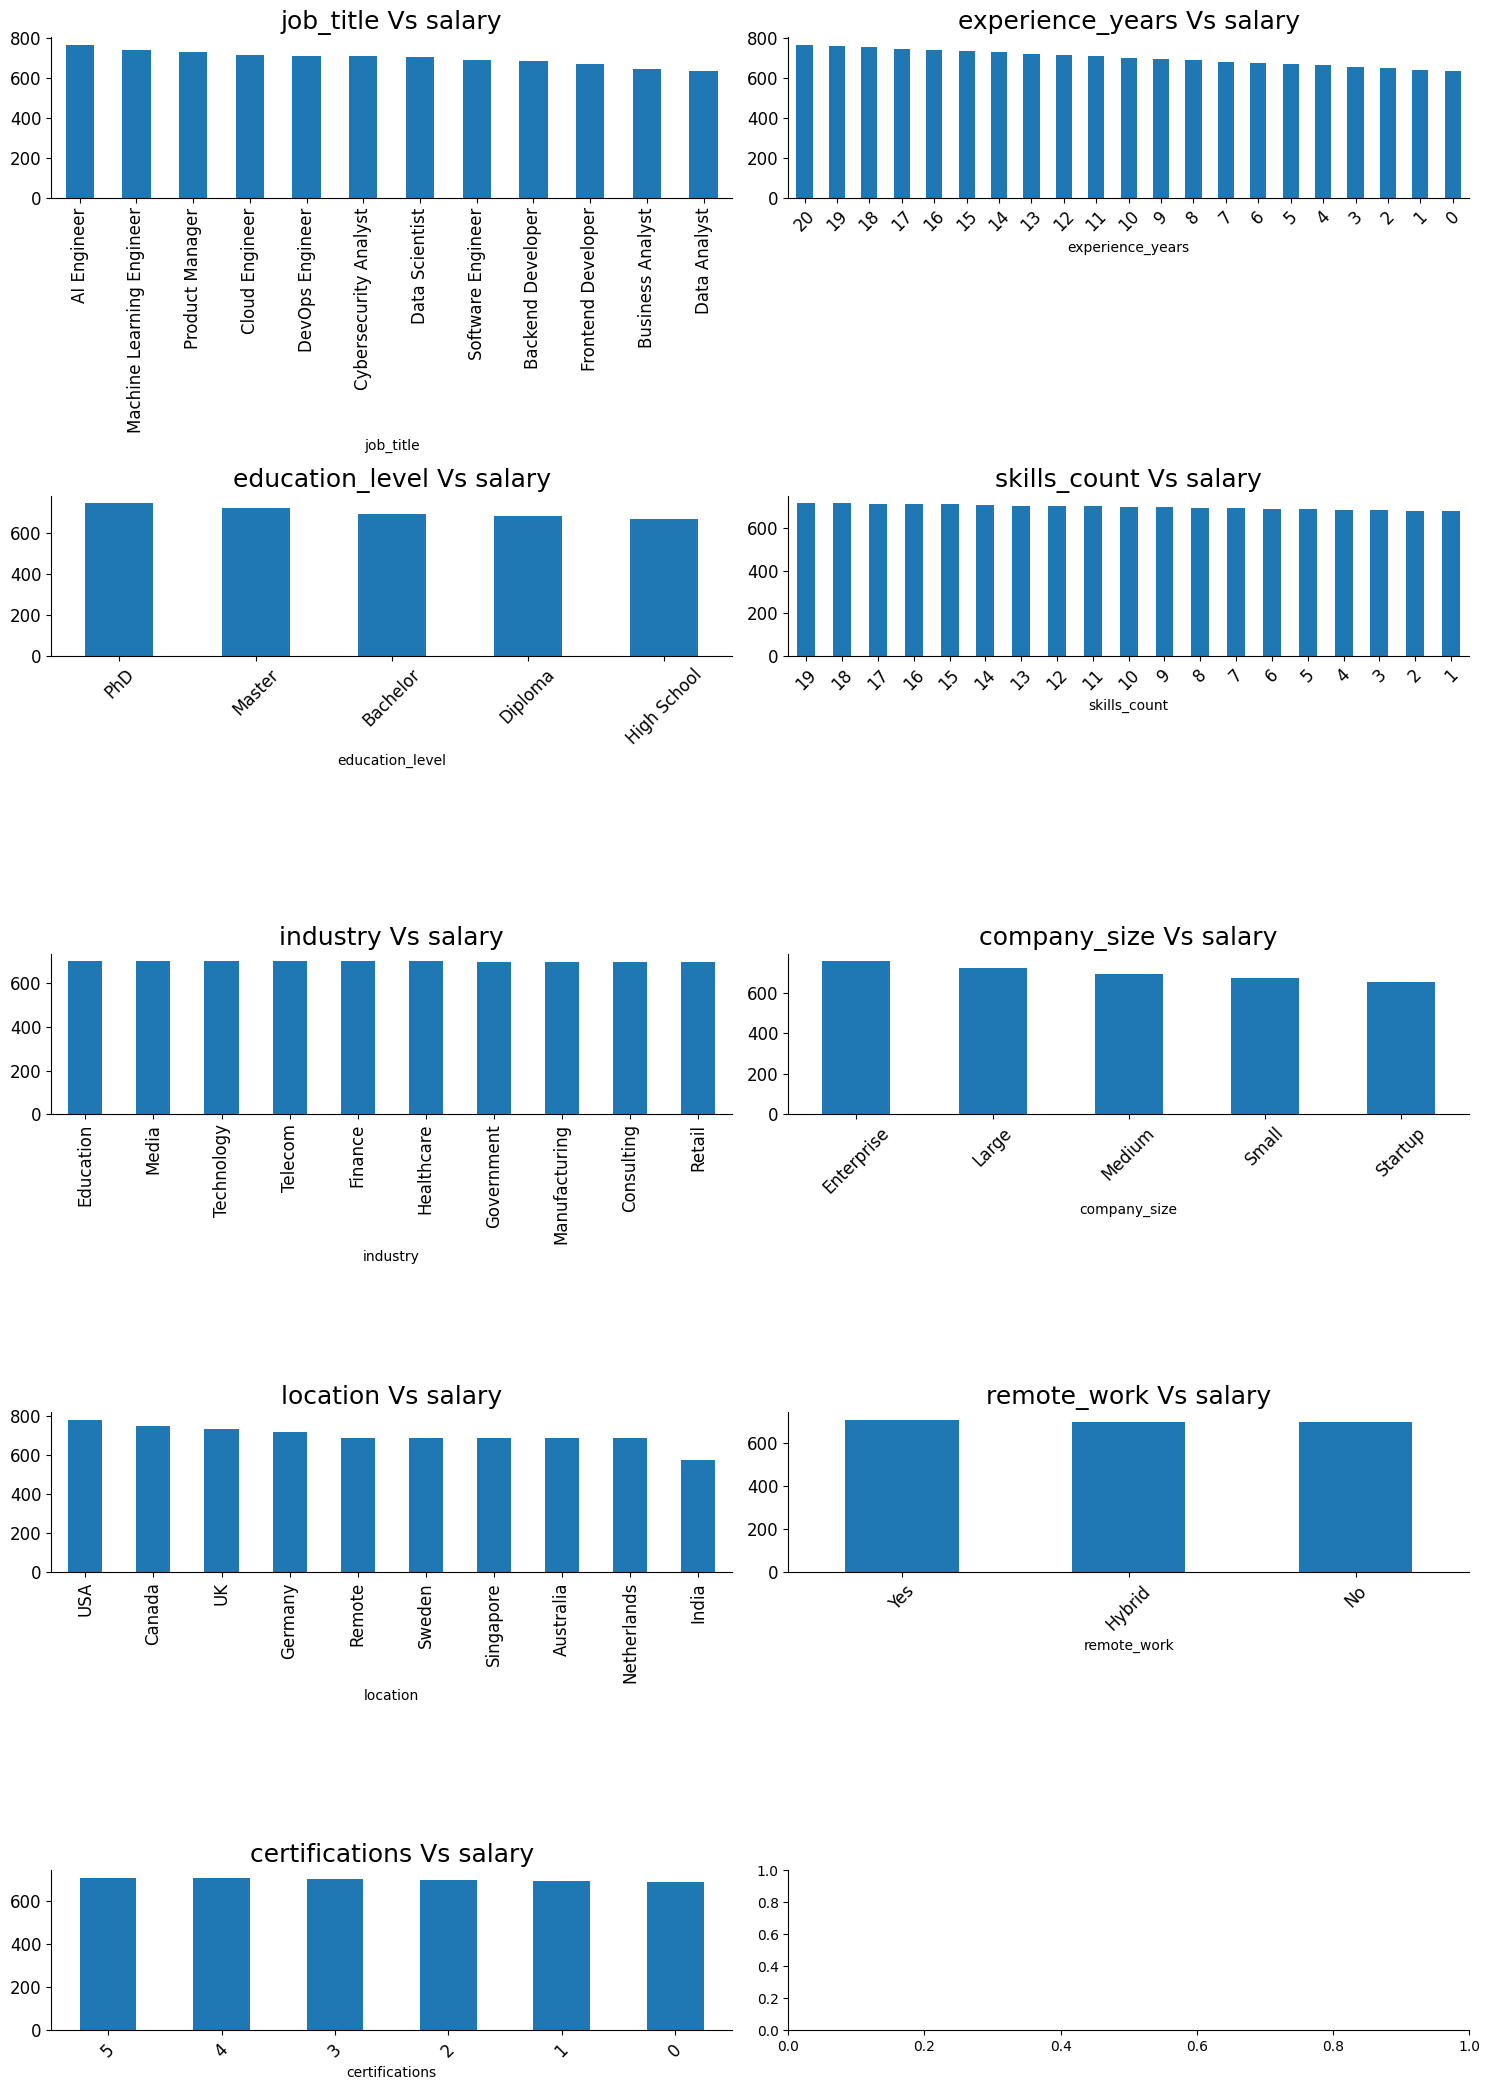

In [10]:
fig, axarr = plt.subplots(5, 2, figsize=(15, 21))
df.groupby('job_title')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][0], fontsize=12)
axarr[0][0].set_title("job_title Vs salary", fontsize=18)
axarr[0][0].tick_params(axis='x', rotation=90)

df.groupby('experience_years')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[0][1], fontsize=12)
axarr[0][1].set_title("experience_years Vs salary", fontsize=18)
axarr[0][1].tick_params(axis='x', rotation=45)

df.groupby('education_level')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][0], fontsize=12)
axarr[1][0].set_title("education_level Vs salary", fontsize=18)
axarr[1][0].tick_params(axis='x', rotation=45)

df.groupby('skills_count')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[1][1], fontsize=12)
axarr[1][1].set_title("skills_count Vs salary", fontsize=18)
axarr[1][1].tick_params(axis='x', rotation=45)

df.groupby('industry')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[2][0], fontsize=12)
axarr[2][0].set_title("industry Vs salary", fontsize=18)
axarr[2][0].tick_params(axis='x', rotation=90)

df.groupby('company_size')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[2][1], fontsize=12)
axarr[2][1].set_title("company_size Vs salary", fontsize=18)
axarr[2][1].tick_params(axis='x', rotation=45)

df.groupby('location')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[3][0], fontsize=12)
axarr[3][0].set_title("location Vs salary", fontsize=18)
axarr[3][0].tick_params(axis='x', rotation=90)

df.groupby('remote_work')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[3][1], fontsize=12)
axarr[3][1].set_title("remote_work Vs salary", fontsize=18)
axarr[3][1].tick_params(axis='x', rotation=45)

df.groupby('certifications')['salary'].mean().sort_values(ascending=False).plot.bar(ax=axarr[4][0], fontsize=12)
axarr[4][0].set_title("certifications Vs salary", fontsize=18)
axarr[4][0].tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=1.0)
plt.subplots_adjust(wspace=.5)
sns.despine()
plt.tight_layout()

A lot of interesting variations are shown. Categories affect salary. 

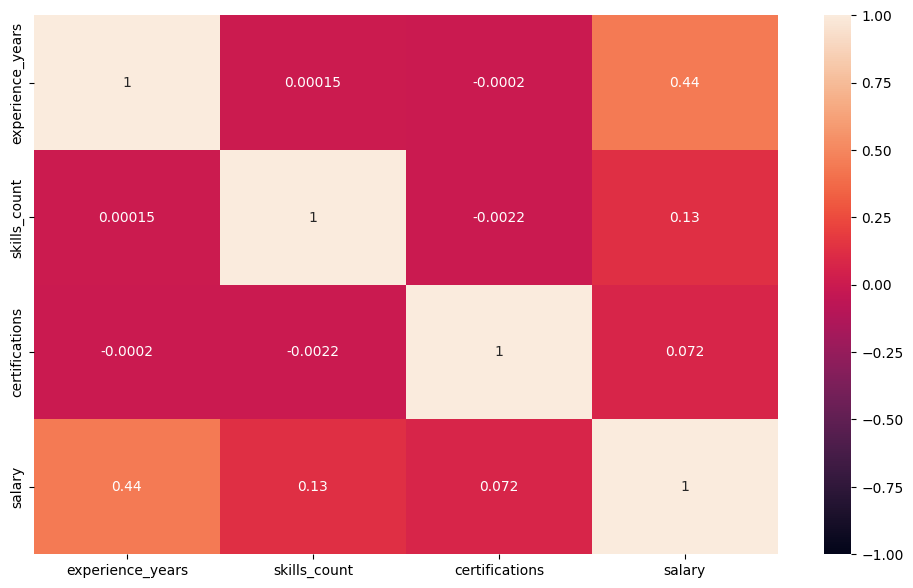

In [11]:
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(method='spearman'), annot = True, vmin = -1, vmax = 1)
plt.show()

Positive correlation between salary and both experience and the number of skills

# Step 5 - Prepare data for ML

Label encoding will be used to change categorical fields into numerical value

In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['job_title'] = le.fit_transform(df['job_title'])
df['education_level'] = le.fit_transform(df['education_level'])
df['industry'] = le.fit_transform(df['industry'])
df['company_size'] = le.fit_transform(df['company_size'])
df['location'] = le.fit_transform(df['location'])
df['remote_work'] = le.fit_transform(df['remote_work'])
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,0,10,0,2,4,2,3,0,2,612.832954
1,5,5,0,17,9,3,0,1,0,567.837100
2,8,18,4,4,6,2,6,1,1,711.727953
3,2,19,4,13,7,2,1,2,0,802.981052
4,10,15,0,7,5,1,7,2,0,750.828549
...,...,...,...,...,...,...,...,...,...,...
249995,11,17,4,2,9,0,3,1,1,661.681426
249996,8,20,4,7,9,4,5,1,2,726.911870
249997,2,1,0,12,7,0,3,2,0,511.806371
249998,6,0,2,2,0,3,7,0,5,557.881357


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['salary'], axis=1), df[['salary']], test_size=0.25, random_state=42)

In [14]:
print("We have {} training records".format(len(X_train)))
print("We have {} testing records".format(len(X_test)))

We have 187500 training records
We have 62500 testing records


# Step 6 - Hyperparameter tuning & Train ML

Will be using Bayesian optimization to find the best hyper parameter values. 

In [15]:
import optuna
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from IPython.display import clear_output

def objective(trial):
    # tol = trial.suggest_float("tol", 1e-15, 1e-6, log=True) No needed because our data is dense. 
    fit_intercept = trial.suggest_categorical("fit_intercept", [True, False])
    positive = trial.suggest_categorical("positive", [True, False])
    
    model = LinearRegression(
        fit_intercept=fit_intercept,
        positive=positive
        )

    model.fit(X_train, y_train)
    predicted_values = model.predict(X_test)
    mse = mean_squared_error(y_test, predicted_values)
    return mse    
 

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)
clear_output()

In [16]:
model = LinearRegression(fit_intercept=study.best_params['fit_intercept'], positive=study.best_params['positive'])
model.fit(X_train, y_train)

LinearRegression(positive=True)

Let's compare the performance of LR against XGBRegressor

In [17]:
import xgboost as xgb

def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 200, 1200, step=50)
    max_depth = trial.suggest_int("max_depth", 1, 7)
    eta = trial.suggest_float("eta", 0.01, 0.5)
    
    xg_model = xgb.XGBRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        eta=eta,
        device='cuda'
    )

    xg_model.fit(X_train, y_train)
    predicted_values = xg_model.predict(X_test)
    mse = mean_squared_error(y_test, predicted_values)
    return mse    
 
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
clear_output()

In [18]:
print(study.best_params)
xg_model = xgb.XGBRegressor(
        n_estimators=study.best_params['n_estimators'],
        max_depth=study.best_params['max_depth'],
        eta=study.best_params['eta']
    )
xg_model.fit(X_train, y_train)

{'n_estimators': 1100, 'max_depth': 3, 'eta': 0.42355024067223324}


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eta=0.42355024067223324,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1100, n_jobs=None, ...)

# Step 7 - Evaluate ML with regression metrics

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* R-squared (R²) Score
* Root Mean Squared Error (RMSE)

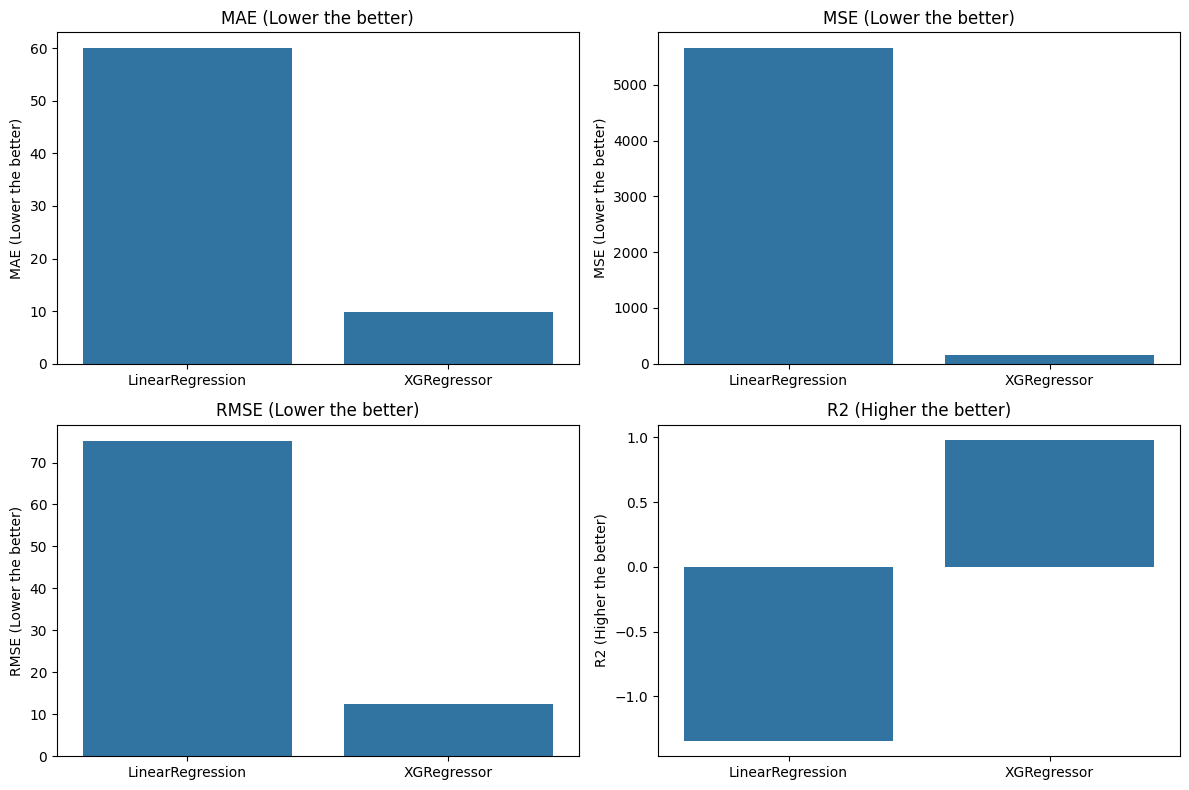

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

predicted_values_lr = model.predict(X_test)
predicted_values_xg = xg_model.predict(X_test)

mae_lr = mean_absolute_error(predicted_values_lr, y_test)
mae_xg = mean_absolute_error(predicted_values_xg, y_test)

mse_lr = mean_squared_error(predicted_values_lr, y_test)
mse_xg = mean_squared_error(predicted_values_xg, y_test)

r2_lr = r2_score(predicted_values_lr, y_test)
r2_xg = r2_score(predicted_values_xg, y_test)

rmse_lr = np.sqrt(mean_squared_error(predicted_values_lr, y_test))
rmse_xg = np.sqrt(mean_squared_error(predicted_values_xg, y_test))

df_eval = pd.DataFrame({
    "Model": ["LinearRegression", "XGRegressor"],
    "MAE (Lower the better)": [mae_lr, mae_xg],
    "MSE (Lower the better)": [mse_lr, mse_xg],
    "RMSE (Lower the better)": [rmse_lr, rmse_xg],
    "R2 (Higher the better)": [r2_lr, r2_xg]
})

# Create 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

metrics = ["MAE (Lower the better)", "MSE (Lower the better)", "RMSE (Lower the better)", "R2 (Higher the better)"]

for i, metric in enumerate(metrics):
    sns.barplot(
        x="Model",
        y=metric,
        data=df_eval,
        ax=axes[i]
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# Step 8 - ML Diagnostics

XGBRegressor outperforms LR across all metrics

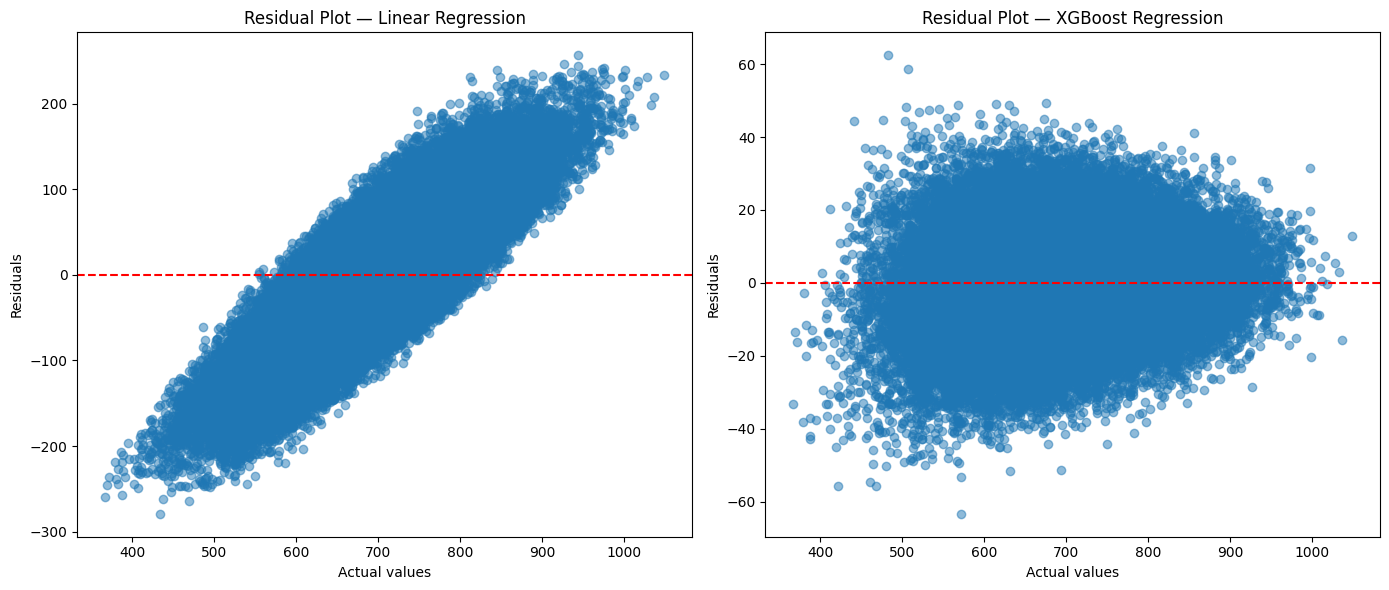

In [20]:
import matplotlib.pyplot as plt

# Residuals
res_lr = y_test - predicted_values_lr
res_xg = y_test.values.ravel() - predicted_values_xg

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Linear Regression ---
axes[0].scatter(y_test, res_lr, alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel("Actual values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot — Linear Regression")

# --- XGBoost Regression ---
axes[1].scatter(y_test.values.ravel(), res_xg, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel("Actual values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot — XGBoost Regression")

plt.tight_layout()
plt.show()

### LR
* LR has large residual (+- 200) which means it is underfitting. I
* It did not capture the nonlinear interaction.
* The residuals increase as the actual values increases (heteroscedastic)

### XGBRegressor
* much smaller error range; better prediction.
* The model captured the underlying structure quite well.
* Almost homoscedastic since it has a roughly constant spread across the entire range. 

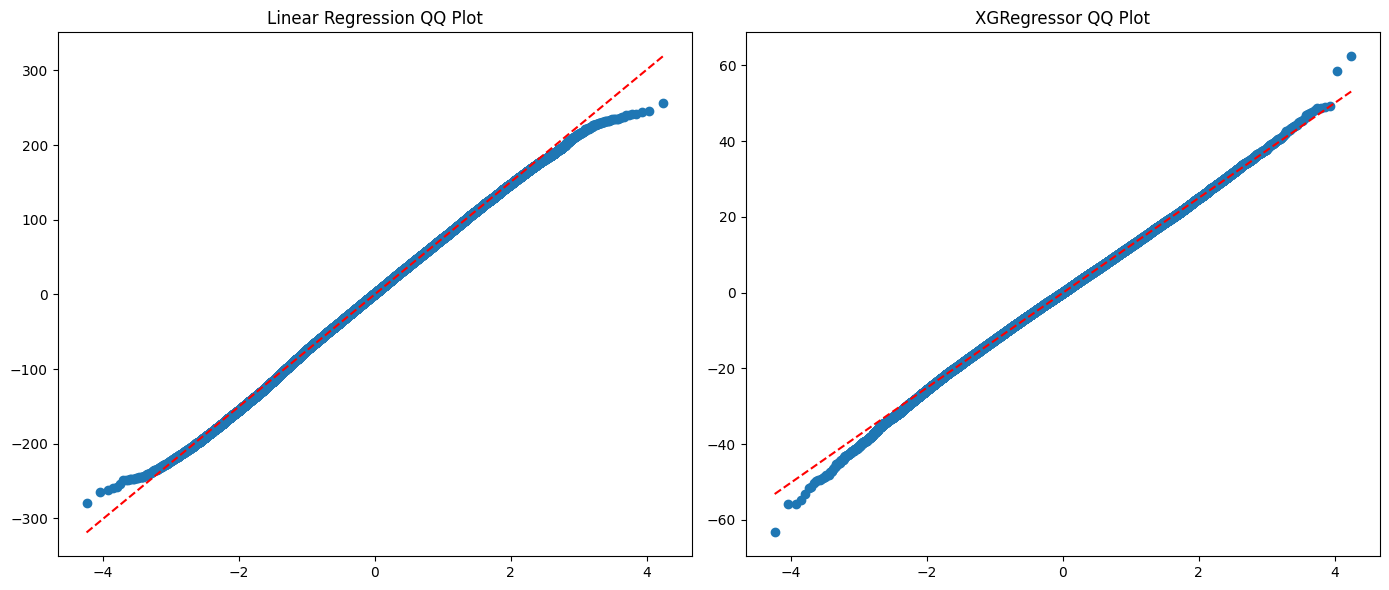

In [21]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(14, 6))


# Linear Regression
(osm, osr), (slope, intercept, r) = stats.probplot(
    np.asarray(res_lr).ravel(), dist="norm"
)
axs[0].plot(osm, osr, 'o')
axs[0].plot(osm, slope * osm + intercept, 'r--')
axs[0].set_title("Linear Regression QQ Plot")


# XGBoost
(osm, osr), (slope, intercept, r) = stats.probplot(
    np.asarray(res_xg).ravel(), dist="norm"
)
axs[1].plot(osm, osr, 'o')
axs[1].plot(osm, slope * osm + intercept, 'r--')
axs[1].set_title("XGRegressor QQ Plot")

plt.tight_layout()
plt.show()

### LR

* Heavy-tailed residuals
* Residuals are more extreme than a normal distribution would predict
* Heteroscedastic

### XGBRegressor

* Residual distribution is close to normal
* Tail deviations are mild
* Homoscedastic

# Step 9 - Convert transformed salary back to original 

In [22]:
predicted_10 = xg_model.predict(X_test.iloc[:10]).ravel()

# compare in a table
df_check = pd.DataFrame({
    "Actual": inv_boxcox(y_test.iloc[:10].to_numpy().ravel(), lambda_opt),
    "Predicted": inv_boxcox(predicted_10, lambda_opt),
})

df_check

,Actual,Predicted
0,164009.0,170333.815419
1,79594.0,92075.540442
2,74090.0,74710.536287
3,177193.0,168720.228388
4,120012.0,116198.020391
5,163369.0,167770.369757
6,111889.0,111995.534816
7,75418.0,73810.934112
8,103067.0,96979.140764
9,190692.0,187462.534036


## Thank you for reviewing this notebook. Any feedback or suggestions would be greatly appreciated.
